# 04 - FaceNet512 Regularized Training

Khắc phục overfitting ở FaceNet512 bằng:
- **K-Fold Cross-Validation** (5-fold) cho kết quả đáng tin cậy
- **Stronger regularization**: L2=5e-4, Dropout tăng
- **Simpler MLP**: giảm capacity (512→256→128→1)
- **So sánh trực tiếp** train-test gap

Kết quả lưu tại `logs/my_logs/Facenet512_*_regularized/`

In [1]:
import os, pickle, time, gc, platform
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import psutil
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, classification_report,
    roc_auc_score, balanced_accuracy_score, accuracy_score, confusion_matrix
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('Python:', platform.python_version())
print('CPU cores:', psutil.cpu_count(logical=True))


TensorFlow: 2.20.0
Keras: 3.12.0
Python: 3.12.0
CPU cores: 16


In [2]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'notebooks')):
    PROJECT_ROOT = os.getcwd()

PKL_DIR     = os.path.join(PROJECT_ROOT, 'models', 'precomputed')
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'lfw_funneled')
PAIRS_FILE  = os.path.join(DATASET_DIR, 'pairs.txt')
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'logs', 'my_logs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: x:\sv3_hk2\graduation_thesis\facenet


In [3]:
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    print(f'{len(pairs)} pairs (same={sum(l==1 for _,_,l in pairs)}, diff={sum(l==0 for _,_,l in pairs)})')
    return pairs

def load_pkl_remap(pkl_path, new_base):
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.normpath(os.path.join(new_base, rel))
        else:
            new_key = k
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} from {os.path.basename(pkl_path)}')
    return remapped

def build_features_concat(pairs, emb_dict):
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.concatenate([np.abs(e1-e2), e1*e2])); y.append(lbl)
    return np.array(X), np.array(y)

In [4]:
# ---- MLP Architectures with Stronger Regularization ----

def build_mlp_reg1(dim):
    """512->256->128->1, L2=5e-4, higher dropout."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_reg2(dim):
    """256->128->64->1, stronger L2=1e-3."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_reg3(dim):
    """768->384->128->1, balanced."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(768, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(384, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

MLP_CONFIGS = [
    ('Reg1_512x256x128', build_mlp_reg1),
    ('Reg2_256x128x64', build_mlp_reg2),
    ('Reg3_768x384x128', build_mlp_reg3),
]

In [5]:
# ============================================================
# Evaluation utilities
# ============================================================

def compute_eer(yt, ys, n_thresholds=1000):
    """Compute Equal Error Rate (EER) and its decision threshold.

    EER is the point where FAR and FRR are closest.
    Lower EER indicates better biometric verification performance.
    """
    yt = np.asarray(yt).astype(int)
    ys = np.asarray(ys).astype(float)
    ths = np.linspace(0, 1, n_thresholds)
    far_list, frr_list = [], []
    for t in ths:
        yp = (ys >= t).astype(int)
        fp = np.sum((yp == 1) & (yt == 0))
        tn = np.sum((yp == 0) & (yt == 0))
        fn = np.sum((yp == 0) & (yt == 1))
        tp = np.sum((yp == 1) & (yt == 1))
        far_list.append(fp / (fp + tn + 1e-9))
        frr_list.append(fn / (fn + tp + 1e-9))
    far = np.array(far_list)
    frr = np.array(frr_list)
    idx = np.argmin(np.abs(far - frr))
    return float((far[idx] + frr[idx]) / 2), float(ths[idx]), float(far[idx]), float(frr[idx])


def safe_auc(y_true, y_score):
    """Return ROC-AUC safely. If only one class exists, return NaN."""
    try:
        return float(roc_auc_score(y_true, y_score))
    except ValueError:
        return np.nan


def confusion_rates(y_true, y_pred):
    """Return TP, TN, FP, FN, FAR, FRR, specificity."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    far = fp / (fp + tn + 1e-9)   # False Acceptance Rate
    frr = fn / (fn + tp + 1e-9)   # False Rejection Rate
    specificity = tn / (tn + fp + 1e-9)
    return {
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'far': float(far), 'frr': float(frr), 'specificity': float(specificity)
    }


def compute_full_metrics(y_true, y_score, threshold=0.5):
    """Compute classification + biometric metrics for face verification."""
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    eer, eer_threshold, eer_far, eer_frr = compute_eer(y_true, y_score)
    rates = confusion_rates(y_true, y_pred)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'specificity': rates['specificity'],
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'auc': safe_auc(y_true, y_score),
        'far': rates['far'],
        'frr': rates['frr'],
        'eer': eer,
        'eer_threshold': eer_threshold,
        'eer_far': eer_far,
        'eer_frr': eer_frr,
        'tp': rates['tp'], 'tn': rates['tn'], 'fp': rates['fp'], 'fn': rates['fn'],
    }


def get_process_ram_mb():
    """Current RAM usage of this Python process in MB."""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


def benchmark_predict(model, X, batch_size=64, warmup=True):
    """Benchmark prediction speed and resource usage.

    Returns predicted scores and resource metrics:
    - latency_ms_per_sample: average inference latency per sample
    - throughput_samples_per_sec: samples processed per second
    - fps: same as throughput, useful for webcam context
    - cpu_percent_total: CPU usage normalized by all logical cores
    - cpu_percent_single_core_equiv: CPU usage as single-core equivalent
    - ram_before_mb, ram_after_mb, ram_delta_mb
    """
    X = np.asarray(X)
    n = len(X)
    process = psutil.Process(os.getpid())

    if warmup and n > 0:
        _ = model.predict(X[:min(batch_size, n)], batch_size=batch_size, verbose=0)

    gc.collect()
    ram_before = get_process_ram_mb()
    cpu_before = process.cpu_times()
    wall_start = time.perf_counter()

    y_score = model.predict(X, batch_size=batch_size, verbose=0).flatten()

    wall_time = time.perf_counter() - wall_start
    cpu_after = process.cpu_times()
    ram_after = get_process_ram_mb()

    cpu_time = (cpu_after.user + cpu_after.system) - (cpu_before.user + cpu_before.system)
    logical_cores = psutil.cpu_count(logical=True) or 1

    latency_ms = (wall_time / max(n, 1)) * 1000
    throughput = n / wall_time if wall_time > 0 else np.nan

    return y_score, {
        'num_samples': int(n),
        'total_predict_time_s': float(wall_time),
        'latency_ms_per_sample': float(latency_ms),
        'throughput_samples_per_sec': float(throughput),
        'fps': float(throughput),
        'cpu_time_s': float(cpu_time),
        'cpu_percent_total': float((cpu_time / (wall_time * logical_cores + 1e-9)) * 100),
        'cpu_percent_single_core_equiv': float((cpu_time / (wall_time + 1e-9)) * 100),
        'ram_before_mb': float(ram_before),
        'ram_after_mb': float(ram_after),
        'ram_delta_mb': float(ram_after - ram_before),
    }


def plot_confusion_matrix(y_true, y_pred, classes, output_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm, interpolation='nearest')
    plt.title('Confusion Matrix', fontsize=13)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})", ha="center", va="center",
                     color="white" if cm_norm[i,j] > cm_norm.max()/2 else "black",
                     fontsize=10, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{output_path}/confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()


In [6]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
print('Ready!')

5996 pairs (same=2998, diff=2998)
Ready!


---
## 5-Fold Cross-Validation + Regularized Training
So sánh regularization strategies trên cả 2 detectors.

---
## Bộ độ đo được bổ sung
Notebook này đánh giá mô hình theo ba nhóm chỉ số:

1. **Prediction Performance**: Accuracy, Balanced Accuracy, Precision, Recall, Specificity, F1-score, ROC-AUC, FAR, FRR, EER và ngưỡng EER.
2. **Computational Performance**: latency trung bình trên mỗi mẫu, throughput/FPS, CPU usage, RAM usage.
3. **Model Complexity**: số lượng parameters và dung lượng model sau khi lưu.

Các chỉ số này giúp so sánh mô hình không chỉ theo độ chính xác, mà còn theo khả năng triển khai thực tế trên hệ thống nhận diện khuôn mặt thời gian thực.


In [7]:
EPOCHS = 24
N_FOLDS = 5

DETECTORS = [
    ('mtcnn', 'Facenet512_mtcnn_embeddings.pkl'),
    ('retinaface', 'Facenet512_retinaface_embeddings.pkl'),
]

all_cv_results = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for detector, pkl_file in DETECTORS:
    pkl_path = os.path.join(PKL_DIR, pkl_file)
    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_features_concat(pairs, emb_dict)
    print(f'{detector}: X={X.shape}')

    for mlp_name, build_mlp_fn in MLP_CONFIGS:
        tag = f'Facenet512_{detector}_{mlp_name}'
        od  = os.path.join(OUTPUT_DIR, tag)
        os.makedirs(od, exist_ok=True)
        print(f'\n{"="*55}\n {tag}\n{"="*55}')

        fold_metrics = []
        fold = 1
        for train_idx, val_idx in skf.split(X, y):
            print(f'\n--- Fold {fold}/{N_FOLDS} ---')
            Xtr_f, Xval_f = X[train_idx], X[val_idx]
            ytr_f, yval_f = y[train_idx], y[val_idx]

            mlp = build_mlp_fn(Xtr_f.shape[1])
            callbacks = [
                keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
            ]
            hist = mlp.fit(Xtr_f, ytr_f, epochs=EPOCHS, batch_size=64,
                          validation_data=(Xval_f, yval_f), callbacks=callbacks, verbose=0)

            # Prediction + resource benchmark on validation fold
            ys, perf = benchmark_predict(mlp, Xval_f, batch_size=64, warmup=True)
            m = compute_full_metrics(yval_f, ys, threshold=0.5)
            yp = (ys >= 0.5).astype(int)

            tra_hist = hist.history['accuracy'][-1]
            val_loss_hist = hist.history['val_loss'][-1]

            fold_row = {
                'fold': fold,
                'train_acc': round(tra_hist, 4),
                'val_acc': round(m['accuracy'], 4),
                'balanced_accuracy': round(m['balanced_accuracy'], 4),
                'val_loss': round(val_loss_hist, 4),
                'precision': round(m['precision'], 4),
                'recall': round(m['recall'], 4),
                'specificity': round(m['specificity'], 4),
                'f1': round(m['f1'], 4),
                'auc': round(m['auc'], 4),
                'far': round(m['far'], 4),
                'frr': round(m['frr'], 4),
                'eer': round(m['eer'], 4),
                'eer_threshold': round(m['eer_threshold'], 4),
                'latency_ms': round(perf['latency_ms_per_sample'], 4),
                'fps': round(perf['fps'], 2),
                'cpu_percent_total': round(perf['cpu_percent_total'], 2),
                'ram_after_mb': round(perf['ram_after_mb'], 2),
            }
            fold_metrics.append(fold_row)
            print(
                f"  Fold {fold}: acc={m['accuracy']:.4f}, f1={m['f1']:.4f}, "
                f"auc={m['auc']:.4f}, eer={m['eer']:.4f}, "
                f"latency={perf['latency_ms_per_sample']:.3f} ms/sample, "
                f"cpu={perf['cpu_percent_total']:.2f}%, ram={perf['ram_after_mb']:.1f} MB"
            )
            fold += 1
            tf.keras.backend.clear_session()
            gc.collect()

        # Aggregate CV results
        df_fold = pd.DataFrame(fold_metrics)
        mean_cols = [
            'train_acc','val_acc','balanced_accuracy','precision','recall','specificity',
            'f1','auc','far','frr','eer','eer_threshold','latency_ms','fps','cpu_percent_total','ram_after_mb'
        ]
        std_cols = ['val_acc','f1','auc','eer','latency_ms','fps','cpu_percent_total','ram_after_mb']
        avg = {k: df_fold[k].mean() for k in mean_cols}
        std = {k: df_fold[k].std() for k in std_cols}

        summary = {
            'model': tag,
            'train_acc': round(avg['train_acc'], 4),
            'test_acc': round(avg['val_acc'], 4),
            'val_acc_std': round(std['val_acc'], 4),
            'balanced_accuracy': round(avg['balanced_accuracy'], 4),
            'precision': round(avg['precision'], 4),
            'recall': round(avg['recall'], 4),
            'specificity': round(avg['specificity'], 4),
            'f1': round(avg['f1'], 4),
            'f1_std': round(std['f1'], 4),
            'auc': round(avg['auc'], 4),
            'auc_std': round(std['auc'], 4),
            'far': round(avg['far'], 4),
            'frr': round(avg['frr'], 4),
            'eer': round(avg['eer'], 4),
            'eer_std': round(std['eer'], 4),
            'eer_threshold': round(avg['eer_threshold'], 4),
            'latency_ms': round(avg['latency_ms'], 4),
            'latency_ms_std': round(std['latency_ms'], 4),
            'fps': round(avg['fps'], 2),
            'fps_std': round(std['fps'], 2),
            'cpu_percent_total': round(avg['cpu_percent_total'], 2),
            'cpu_percent_total_std': round(std['cpu_percent_total'], 2),
            'ram_after_mb': round(avg['ram_after_mb'], 2),
            'ram_after_mb_std': round(std['ram_after_mb'], 2),
            'gap_train_test': round(avg['train_acc'] - avg['val_acc'], 4),
        }
        all_cv_results.append(summary)

        # Save fold details
        df_fold.to_csv(os.path.join(od, 'cv_folds.csv'), index=False)
        print(
            f"\nAvg: acc={avg['val_acc']:.4f} ± {std['val_acc']:.4f}, "
            f"f1={avg['f1']:.4f}, auc={avg['auc']:.4f}, eer={avg['eer']:.4f}, "
            f"latency={avg['latency_ms']:.3f}ms, fps={avg['fps']:.2f}, "
            f"cpu={avg['cpu_percent_total']:.2f}%, ram={avg['ram_after_mb']:.1f}MB"
        )


Loaded 7701 from Facenet512_mtcnn_embeddings.pkl
mtcnn: X=(5996, 1024)

 Facenet512_mtcnn_Reg1_512x256x128

--- Fold 1/5 ---
  Fold 1: acc=0.9392, f1=0.9386, auc=0.9779, eer=0.0683, latency=0.661 ms/sample, cpu=6.15%, ram=636.0 MB


--- Fold 2/5 ---
  Fold 2: acc=0.9416, f1=0.9421, auc=0.9830, eer=0.0550, latency=0.619 ms/sample, cpu=6.98%, ram=680.0 MB

--- Fold 3/5 ---
  Fold 3: acc=0.9525, f1=0.9528, auc=0.9816, eer=0.0467, latency=1.098 ms/sample, cpu=5.41%, ram=706.6 MB

--- Fold 4/5 ---
  Fold 4: acc=0.9408, f1=0.9386, auc=0.9810, eer=0.0601, latency=0.331 ms/sample, cpu=5.91%, ram=730.3 MB

--- Fold 5/5 ---
  Fold 5: acc=0.9533, f1=0.9525, auc=0.9836, eer=0.0517, latency=0.224 ms/sample, cpu=7.26%, ram=758.4 MB

Avg: acc=0.9455 ± 0.0068, f1=0.9449, auc=0.9814, eer=0.0564, latency=0.587ms, fps=2304.30, cpu=6.34%, ram=702.2MB

 Facenet512_mtcnn_Reg2_256x128x64

--- Fold 1/5 ---
  Fold 1: acc=0.9475, f1=0.9459, auc=0.9807, eer=0.0633, latency=0.174 ms/sample, cpu=7.01%, ram=772.9 M

In [8]:
df_cv = pd.DataFrame(all_cv_results)
df_cv = df_cv.sort_values('test_acc', ascending=False)
print('\n========== 5-FOLD CV RESULTS (sorted by test_acc) ==========')
print(df_cv.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_CV.csv')
df_cv.to_csv(csv_path, index=False)
print(f'\nSaved to: {csv_path}')


========== 5-FOLD CV RESULTS (sorted by test_acc) ==========
                                 model  train_acc  test_acc  val_acc_std  balanced_accuracy  precision  recall  specificity     f1  f1_std    auc  auc_std    far    frr    eer  eer_std  eer_threshold  latency_ms  latency_ms_std     fps  fps_std  cpu_percent_total  cpu_percent_total_std  ram_after_mb  ram_after_mb_std  gap_train_test
Facenet512_retinaface_Reg1_512x256x128     0.9947    0.9641       0.0043             0.9641     0.9721  0.9560       0.9723 0.9639  0.0041 0.9899   0.0014 0.0277 0.0440 0.0390   0.0040         0.3371      0.1928          0.0181 5222.66   460.22               8.82                   1.22       1093.73             37.75          0.0306
Facenet512_retinaface_Reg3_768x384x128     0.9946    0.9626       0.0074             0.9626     0.9712  0.9540       0.9713 0.9623  0.0071 0.9897   0.0022 0.0287 0.0460 0.0404   0.0052         0.3035      0.2153          0.0648 4962.19  1320.38               7.77     

In [9]:
print('\n=== BEST MODEL PER METRIC ===')
for metric in ['test_acc', 'f1', 'auc']:
    best = df_cv.loc[df_cv[metric].idxmax()]
    std_col = 'val_acc_std' if metric == 'test_acc' else f'{metric}_std'
    print(f'{metric}: {best["model"]} ({best[metric]:.4f} ± {best.get(std_col, np.nan):.4f})')

for metric in ['eer', 'far', 'frr', 'latency_ms', 'cpu_percent_total', 'ram_after_mb', 'gap_train_test']:
    best = df_cv.loc[df_cv[metric].idxmin()]
    print(f'{metric} (lower): {best["model"]} ({best[metric]:.4f})')

print('\n=== OVERFITTING GAP ANALYSIS ===')
print('Model with smallest train-test gap (least overfit):')
best_gap = df_cv.loc[df_cv['gap_train_test'].idxmin()]
print(f'  {best_gap["model"]} (gap={best_gap["gap_train_test"]:.4f})')
print('Model with largest gap (most overfit):')
worst_gap = df_cv.loc[df_cv['gap_train_test'].idxmax()]
print(f'  {worst_gap["model"]} (gap={worst_gap["gap_train_test"]:.4f})')

print('\n=== DEPLOYMENT TRADE-OFF SUMMARY ===')
cols = ['model', 'test_acc', 'f1', 'auc', 'eer', 'far', 'frr', 'latency_ms', 'fps', 'cpu_percent_total', 'ram_after_mb']
print(df_cv[cols].to_string(index=False))



=== BEST MODEL PER METRIC ===
test_acc: Facenet512_retinaface_Reg1_512x256x128 (0.9641 ± 0.0043)
f1: Facenet512_retinaface_Reg1_512x256x128 (0.9639 ± 0.0041)
auc: Facenet512_retinaface_Reg1_512x256x128 (0.9899 ± 0.0014)
eer (lower): Facenet512_retinaface_Reg1_512x256x128 (0.0390)
far (lower): Facenet512_retinaface_Reg1_512x256x128 (0.0277)
frr (lower): Facenet512_retinaface_Reg1_512x256x128 (0.0440)
latency_ms (lower): Facenet512_mtcnn_Reg2_256x128x64 (0.1913)
cpu_percent_total (lower): Facenet512_mtcnn_Reg1_512x256x128 (6.3400)
ram_after_mb (lower): Facenet512_mtcnn_Reg1_512x256x128 (702.2500)
gap_train_test (lower): Facenet512_retinaface_Reg2_256x128x64 (0.0304)

=== OVERFITTING GAP ANALYSIS ===
Model with smallest train-test gap (least overfit):
  Facenet512_retinaface_Reg2_256x128x64 (gap=0.0304)
Model with largest gap (most overfit):
  Facenet512_mtcnn_Reg3_768x384x128 (gap=0.0481)

=== DEPLOYMENT TRADE-OFF SUMMARY ===
                                 model  test_acc     f1    au

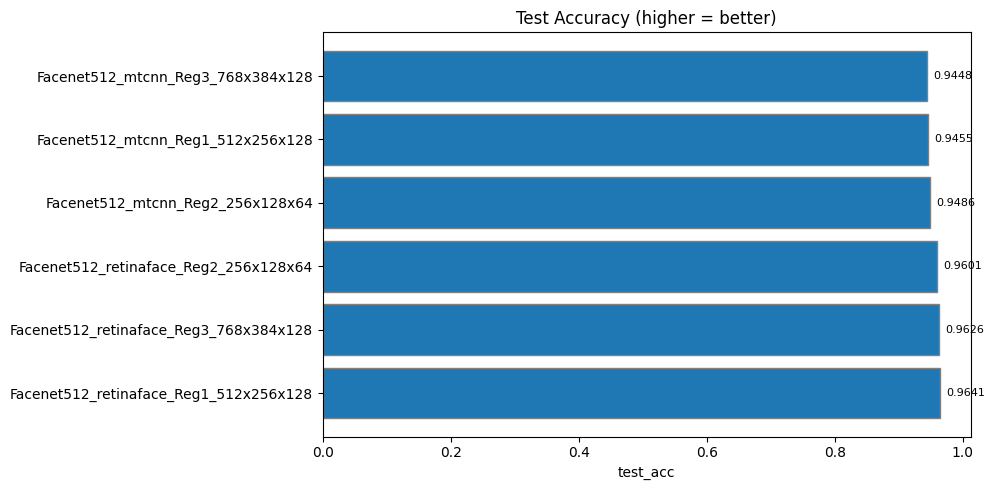

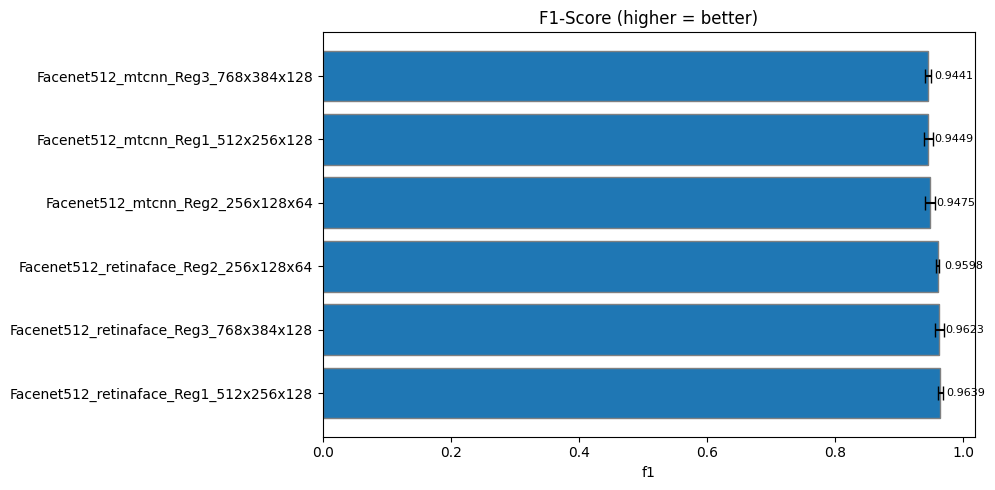

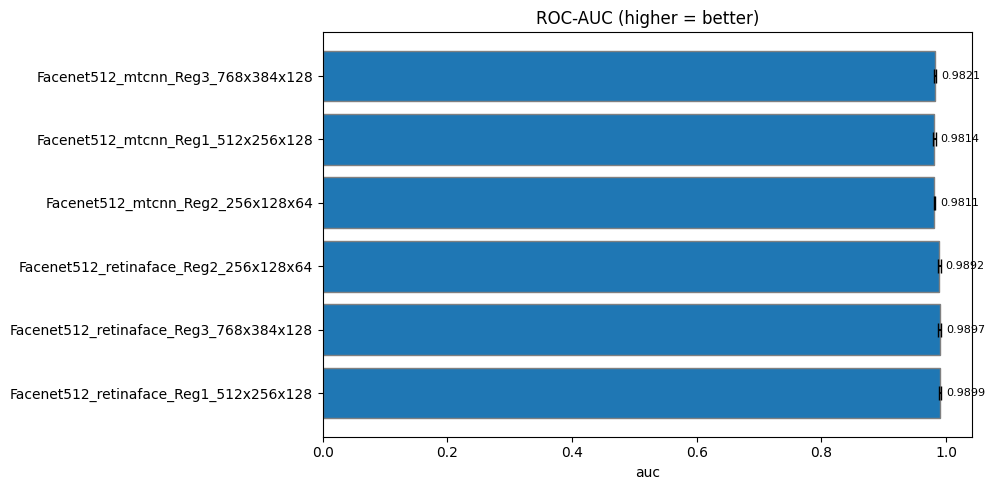

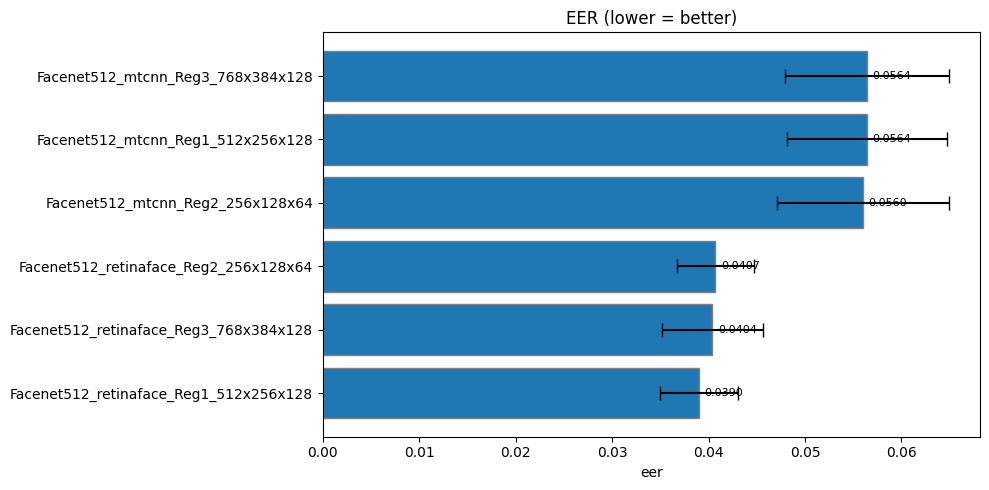

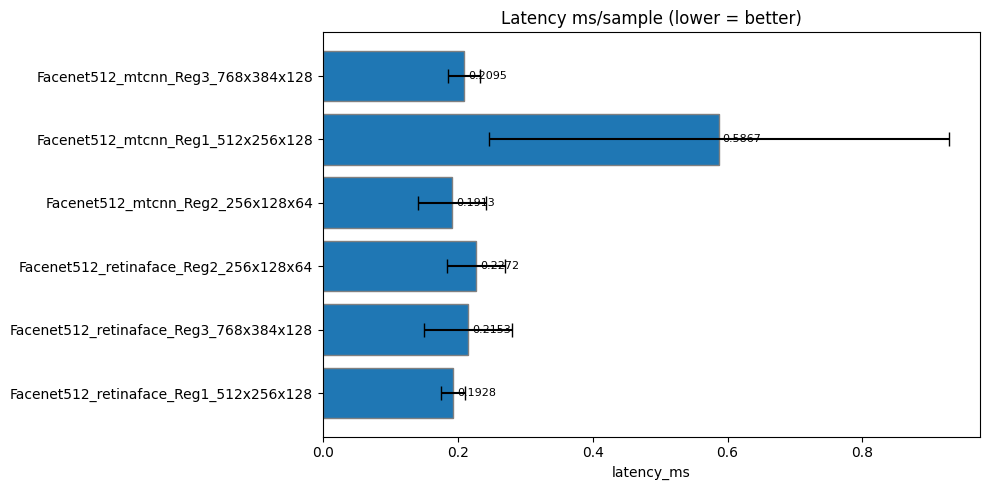

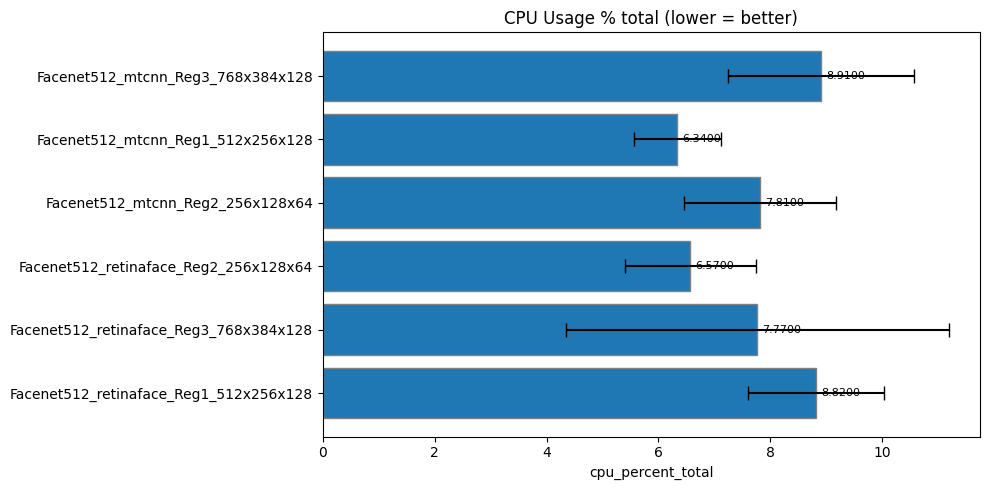

Done!


In [10]:
# Plot: accuracy, F1, AUC, EER, latency, resource usage
plot_metrics = [
    ('test_acc', 'Test Accuracy (higher = better)'),
    ('f1', 'F1-Score (higher = better)'),
    ('auc', 'ROC-AUC (higher = better)'),
    ('eer', 'EER (lower = better)'),
    ('latency_ms', 'Latency ms/sample (lower = better)'),
    ('cpu_percent_total', 'CPU Usage % total (lower = better)'),
]

for metric, title in plot_metrics:
    plt.figure(figsize=(10, 5))
    vals = df_cv[metric]
    err_col = f'{metric}_std'
    err = df_cv[err_col] if err_col in df_cv.columns else None
    bars = plt.barh(df_cv['model'], vals, xerr=err, edgecolor='gray', capsize=5)
    plt.title(title, fontsize=12)
    plt.xlabel(metric)
    for bar, v in zip(bars, vals):
        plt.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}' if abs(v) < 10 else f'{v:.2f}', va='center', fontsize=8)
    plt.tight_layout()
    fname = f'comparison_{metric}_facenet512_regularized.png'
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Done!')


---
## Full Training on Best Configurations
Train top-2 configs on full data (80/20 split) + save predictions.

In [11]:
# Pick top configs for each detector (by test_acc)
best_configs = []
for detector in ['mtcnn', 'retinaface']:
    sub = df_cv[df_cv['model'].str.contains(detector)]
    if len(sub) == 0: continue
    best_row = sub.loc[sub['test_acc'].idxmax()]
    # Find which MLP config it matches
    mlp_name = best_row['model'].replace(f'Facenet512_{detector}_', '')
    for name, fn in MLP_CONFIGS:
        if name == mlp_name:
            pkl_file = f'Facenet512_{detector}_embeddings.pkl'
            best_configs.append((detector, pkl_file, name, fn))
            break

print('Best configs for full training:')
for det, pkl, name, fn in best_configs:
    print(f'  {det}: {name}')

Best configs for full training:
  mtcnn: Reg2_256x128x64
  retinaface: Reg1_512x256x128



 FULL TRAIN: Facenet512_mtcnn_Reg2_256x128x64_regularized
Loaded 7701 from Facenet512_mtcnn_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8305 - loss: 1.0468 - val_accuracy: 0.9125 - val_loss: 0.9856 - learning_rate: 3.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9230 - loss: 0.8776 - val_accuracy: 0.9333 - val_loss: 0.9037 - learning_rate: 3.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9328 - loss: 0.8491 - val_accuracy: 0.9389 - val_loss: 0.8610 - learning_rate: 3.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9382 - loss: 0.8186 - val_accuracy: 0.9417 - val_loss: 0.8255 - learning_rate: 3.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9428 - loss: 0.7844 - val_accuracy: 0.9403 - val_loss: 0.8092 - learning_rate: 3.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9455 - loss: 0.7691 - val_accuracy

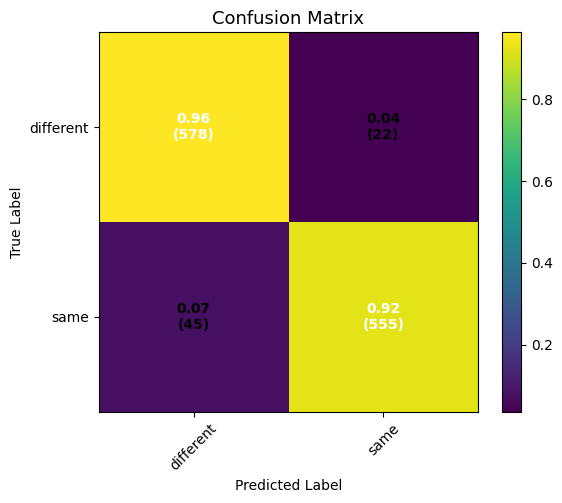

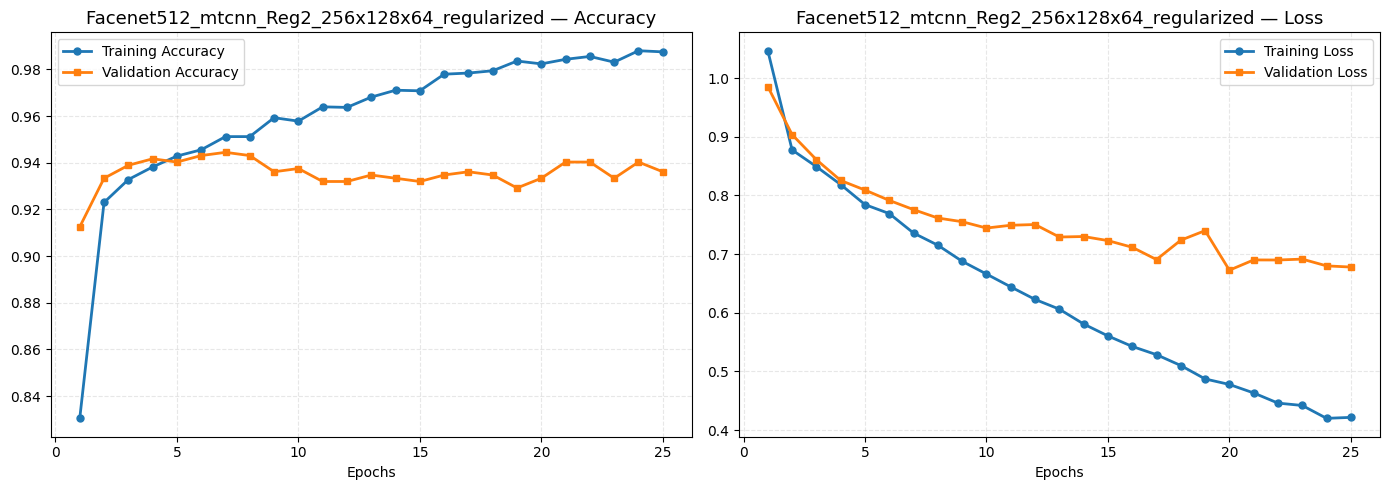


 FULL TRAIN: Facenet512_retinaface_Reg1_512x256x128_regularized
Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8987 - loss: 0.8471 - val_accuracy: 0.9222 - val_loss: 0.9070 - learning_rate: 3.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9531 - loss: 0.7267 - val_accuracy: 0.9375 - val_loss: 0.8299 - learning_rate: 3.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9627 - loss: 0.6969 - val_accuracy: 0.9500 - val_loss: 0.7769 - learning_rate: 3.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9686 - loss: 0.6688 - val_accuracy: 0.9514 - val_loss: 0.7482 - learning_rate: 3.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9733 - loss: 0.6391 - val_accuracy: 0.9500 - val_loss: 0.7491 - learning_rate: 3.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9723 - loss: 0.629

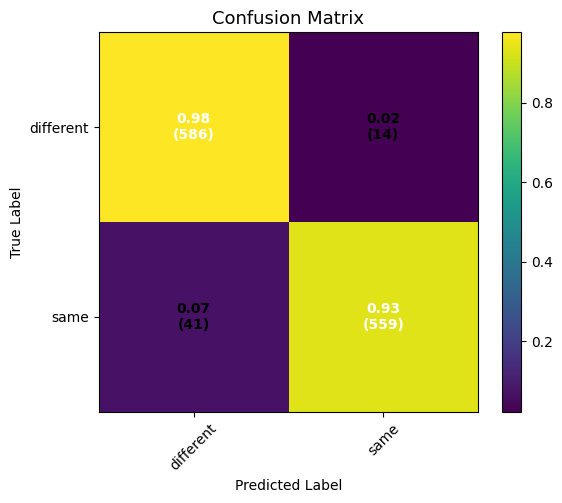

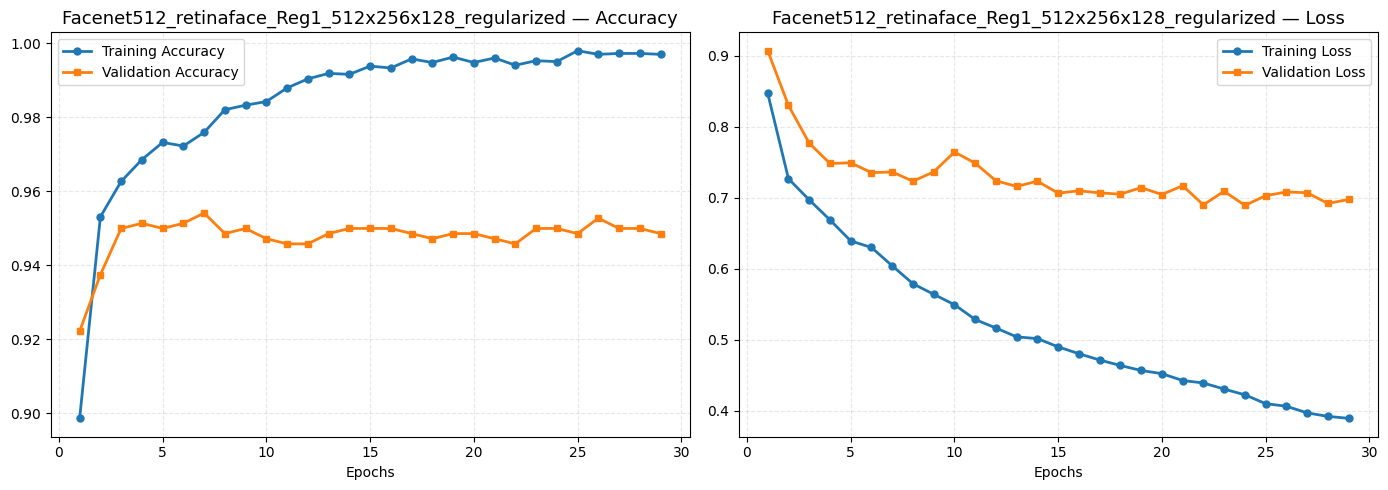


========== FULL TRAINING METRICS ==========
                                             model  test_acc     f1    auc    eer    far    frr  latency_ms     fps  cpu_percent_total  ram_after_mb  parameters  model_size_mb
      Facenet512_mtcnn_Reg2_256x128x64_regularized    0.9442 0.9431 0.9789 0.0583 0.0367 0.0750      0.1508 6629.20               7.01       1487.75      305153           3.53
Facenet512_retinaface_Reg1_512x256x128_regularized    0.9542 0.9531 0.9847 0.0533 0.0233 0.0683      0.1857 5385.63               9.20       1523.55      692225           7.96

Saved full metrics to: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs\MLP_Facenet512_Regularized_FULL_METRICS.csv


In [12]:
EPOCHS_FULL = 30
full_training_results = []

for detector, pkl_file, mlp_name, build_mlp_fn in best_configs:
    tag = f'Facenet512_{detector}_{mlp_name}_regularized'
    od  = os.path.join(OUTPUT_DIR, tag)
    os.makedirs(od, exist_ok=True)
    pkl_path = os.path.join(PKL_DIR, pkl_file)

    print(f'\n{"="*60}\n FULL TRAIN: {tag}\n{"="*60}')

    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_features_concat(pairs, emb_dict)
    print(f'Features: {X.shape}')
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mlp = build_mlp_fn(Xtr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    hist = mlp.fit(Xtr, ytr, epochs=EPOCHS_FULL, batch_size=64,
                   validation_split=0.15, callbacks=callbacks, verbose=1)

    # Prediction benchmark on test set
    ys, perf = benchmark_predict(mlp, Xte, batch_size=64, warmup=True)
    yp = (ys >= 0.5).astype(int)

    trl, tra = mlp.evaluate(Xtr, ytr, verbose=0)
    tel, tea = mlp.evaluate(Xte, yte, verbose=0)
    m = compute_full_metrics(yte, ys, threshold=0.5)

    n_params = int(mlp.count_params())
    model_path = os.path.join(od, 'model.keras')
    mlp.save(model_path)
    model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

    result_row = {
        'model': tag,
        'detector': detector,
        'mlp_config': mlp_name,
        'train_loss': round(float(trl), 4),
        'test_loss': round(float(tel), 4),
        'train_acc': round(float(tra), 4),
        'test_acc': round(float(tea), 4),
        'balanced_accuracy': round(m['balanced_accuracy'], 4),
        'precision': round(m['precision'], 4),
        'recall': round(m['recall'], 4),
        'specificity': round(m['specificity'], 4),
        'f1': round(m['f1'], 4),
        'auc': round(m['auc'], 4),
        'far': round(m['far'], 4),
        'frr': round(m['frr'], 4),
        'eer': round(m['eer'], 4),
        'eer_threshold': round(m['eer_threshold'], 4),
        'tp': m['tp'], 'tn': m['tn'], 'fp': m['fp'], 'fn': m['fn'],
        'overfit_gap': round(float(tra - tea), 4),
        'latency_ms': round(perf['latency_ms_per_sample'], 4),
        'fps': round(perf['fps'], 2),
        'throughput_samples_per_sec': round(perf['throughput_samples_per_sec'], 2),
        'total_predict_time_s': round(perf['total_predict_time_s'], 4),
        'cpu_time_s': round(perf['cpu_time_s'], 4),
        'cpu_percent_total': round(perf['cpu_percent_total'], 2),
        'cpu_percent_single_core_equiv': round(perf['cpu_percent_single_core_equiv'], 2),
        'ram_before_mb': round(perf['ram_before_mb'], 2),
        'ram_after_mb': round(perf['ram_after_mb'], 2),
        'ram_delta_mb': round(perf['ram_delta_mb'], 2),
        'parameters': n_params,
        'model_size_mb': round(model_size_mb, 2),
    }
    full_training_results.append(result_row)

    # Save report
    rpt = f"--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---\nModel: {tag} | Detector: {detector}\n"
    rpt += "\n[Prediction Performance]\n"
    rpt += f"Train Acc: {tra:.4f}\nTest Acc: {tea:.4f}\nBalanced Acc: {m['balanced_accuracy']:.4f}\n"
    rpt += f"Train Loss: {trl:.4f}\nTest Loss: {tel:.4f}\nOverfit Gap: {tra - tea:.4f}\n"
    rpt += f"Precision: {m['precision']:.4f}\nRecall: {m['recall']:.4f}\nSpecificity: {m['specificity']:.4f}\nF1: {m['f1']:.4f}\n"
    rpt += f"ROC-AUC: {m['auc']:.4f}\nFAR: {m['far']:.4f}\nFRR: {m['frr']:.4f}\nEER: {m['eer']:.4f} @ Threshold: {m['eer_threshold']:.4f}\n"
    rpt += f"Confusion Matrix Counts: TP={m['tp']}, TN={m['tn']}, FP={m['fp']}, FN={m['fn']}\n"
    rpt += "\n[Computational Performance]\n"
    rpt += f"Latency: {perf['latency_ms_per_sample']:.4f} ms/sample\n"
    rpt += f"Throughput/FPS: {perf['fps']:.2f} samples/sec\n"
    rpt += f"Total Predict Time: {perf['total_predict_time_s']:.4f} s for {perf['num_samples']} samples\n"
    rpt += f"CPU Usage Total: {perf['cpu_percent_total']:.2f}%\n"
    rpt += f"CPU Single-Core Equivalent: {perf['cpu_percent_single_core_equiv']:.2f}%\n"
    rpt += f"RAM Before/After/Delta: {perf['ram_before_mb']:.2f} / {perf['ram_after_mb']:.2f} / {perf['ram_delta_mb']:.2f} MB\n"
    rpt += f"Parameters: {n_params:,}\nModel Size: {model_size_mb:.2f} MB\n"
    print(rpt)
    with open(os.path.join(od, 'final_report.txt'), 'w', encoding='utf-8') as f:
        f.write(rpt)

    # Save row-level metrics
    pd.DataFrame([result_row]).to_csv(os.path.join(od, 'final_metrics.csv'), index=False)

    # Save predictions for threshold analysis
    pred_df = pd.DataFrame({'y_true': yte, 'y_score': ys, 'y_pred_0_5': yp})
    pred_df.to_csv(os.path.join(od, 'test_predictions.csv'), index=False)

    # Save classification report
    creport = classification_report(yte, yp, target_names=['different', 'same'], zero_division=0)
    with open(os.path.join(od, 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write(creport)

    # Plot confusion matrix
    plot_confusion_matrix(yte, yp, classes=['different', 'same'], output_path=od)

    # Plot training curves
    epochs_r = range(1, len(hist.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (metric_name, title) in zip(axes, [('accuracy', 'Accuracy'), ('loss', 'Loss')]):
        train_v = hist.history[metric_name]
        val_v = hist.history[f'val_{metric_name}']
        ax.plot(epochs_r, train_v, 'o-', label=f'Training {title}', linewidth=2, markersize=5)
        ax.plot(epochs_r, val_v, 's-', label=f'Validation {title}', linewidth=2, markersize=5)
        ax.set_title(f'{tag} — {title}', fontsize=13)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(od, 'training_curves.png'), dpi=150)
    plt.show()
    plt.close()

    tf.keras.backend.clear_session()
    gc.collect()

# Save final comparison table for report/thesis
if full_training_results:
    df_full = pd.DataFrame(full_training_results)
    final_csv = os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_FULL_METRICS.csv')
    df_full.to_csv(final_csv, index=False)
    print('\n========== FULL TRAINING METRICS ==========')
    display_cols = [
        'model','test_acc','f1','auc','eer','far','frr',
        'latency_ms','fps','cpu_percent_total','ram_after_mb','parameters','model_size_mb'
    ]
    print(df_full[display_cols].to_string(index=False))
    print(f'\nSaved full metrics to: {final_csv}')


In [13]:
import glob
regularized_dirs = [d for d in os.listdir(OUTPUT_DIR) if 'regularized' in d]
print('Regularized model results saved in:')
for d in sorted(regularized_dirs):
    report_path = os.path.join(OUTPUT_DIR, d, 'final_report.txt')
    if os.path.exists(report_path):
        with open(report_path, encoding='utf-8') as f:
            first_lines = ''.join(f.readlines()[:18])
        print(f'\n--- {d} ---')
        print(first_lines.strip())

summary_files = [
    os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_CV.csv'),
    os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_FULL_METRICS.csv'),
]
print('\nSummary files:')
for fp in summary_files:
    print(f'  {fp} -> {"FOUND" if os.path.exists(fp) else "not created yet"}')

print(f'\nAll results saved to: {OUTPUT_DIR}')
print('Done!')


Regularized model results saved in:

--- Facenet512_mtcnn_Reg2_256x128x64_regularized ---
--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---
Model: Facenet512_mtcnn_Reg2_256x128x64_regularized | Detector: mtcnn

[Prediction Performance]
Train Acc: 0.9883
Test Acc: 0.9442
Balanced Acc: 0.9442
Train Loss: 0.4697
Test Loss: 0.6290
Overfit Gap: 0.0442
Precision: 0.9619
Recall: 0.9250
Specificity: 0.9633
F1: 0.9431
ROC-AUC: 0.9789
FAR: 0.0367
FRR: 0.0750
EER: 0.0583 @ Threshold: 0.2563

--- Facenet512_retinaface_Reg1_512x256x128_regularized ---
--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---
Model: Facenet512_retinaface_Reg1_512x256x128_regularized | Detector: retinaface

[Prediction Performance]
Train Acc: 0.9925
Test Acc: 0.9542
Balanced Acc: 0.9542
Train Loss: 0.4496
Test Loss: 0.6446
Overfit Gap: 0.0383
Precision: 0.9756
Recall: 0.9317
Specificity: 0.9767
F1: 0.9531
ROC-AUC: 0.9847
FAR: 0.0233
FRR: 0.0683
EER: 0.0533 @ Threshold: 0.0841

Summary files:
  x:\sv3_hk2\graduation_thesis\facene